In [1]:
#importo librerias necesarias
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#importo las bases de datos, t1_24 y t1_25

df1 = pd.read_excel("usu_individual_T125.xlsx")

df2 = pd.read_excel("usu_individual_T124.xlsx")

In [4]:
#creo las variables con las columnas nuevas a analizar en el TP3
t1_25n= df1[["CODUSU", "ANO4", "COMPONENTE", "PP3E_TOT", "PP3F_TOT", "CH12", "CH13", "CH14" ]]
t1_24n= df2[["CODUSU", "ANO4", "COMPONENTE", "PP3E_TOT", "PP3F_TOT", "CH12", "CH13", "CH14" ]]

## Concateno los dataframes 

In [5]:
# agrupo ambos dataset
t1_2425n = pd.concat([t1_24n, t1_25n], ignore_index=True)

# Verificamos que estén ambos años
print(t1_2425n["ANO4"].value_counts())

ANO4
2024    46050
2025    45425
Name: count, dtype: int64


In [6]:
#traigo el dataset del TP anterior
t1_2425 = pd.read_excel("t1_2425.xlsx")
print(t1_2425["ANO4"].value_counts())

ANO4
2024    46050
2025    45425
Name: count, dtype: int64


In [7]:
t1_2425.head()

,CODUSU,ANO4,REGION,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_OCUP,EMPLEO,SECTOR,PP04C,PP04D_COD,P21,P47T,PP04G,PP04A
0,TQRMNOSTSHJOLOCDEHLEH00795168,2024,40,1,140,2,86.0,4,1.0,2,3,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,43,1,648,1,68.0,3,1.0,2,1,2,2.0,2.0,1.0,72113.0,150000.0,280000.0,8.0,2.0
2,TQRMNOSQYHJMLPCDEIKAH00793199,2024,43,1,648,1,20.0,5,1.0,4,2,2,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,TQRMNORWPHJOLLCDEGPDJ00795996,2024,40,1,281,2,75.0,3,1.0,6,3,0,NaN,NaN,NaN,NaN,0.0,400000.0,NaN,NaN
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,2,41.0,1,1.0,4,1,2,2.0,2.0,1.0,57113.0,250000.0,250000.0,12.0,2.0


In [8]:
t1_2425n.head()

,CODUSU,ANO4,COMPONENTE,PP3E_TOT,PP3F_TOT,CH12,CH13,CH14
0,TQRMNOSTSHJOLOCDEHLEH00795168,2024,1,NaN,NaN,2,1,NaN
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,1,6.0,0.0,2,1,NaN
2,TQRMNOSQYHJMLPCDEIKAH00793199,2024,2,NaN,NaN,4,1,NaN
3,TQRMNORWPHJOLLCDEGPDJ00795996,2024,1,NaN,NaN,6,1,NaN
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,1,12.0,0.0,4,1,NaN


In [9]:
#selecciono las columnas nuevas para concatenar con el dataset del TP2
nuevas_cols = t1_2425n[["COMPONENTE", "PP3E_TOT", "PP3F_TOT", "CH12", "CH13", "CH14"]]

#concateno por el eje de las columnas
t1_2425_3 = pd.concat([t1_2425, nuevas_cols], axis=1)

# verfico que no hay filas de más
print(f"Filas originales TP2(t1_2425): {t1_2425.shape[0]}")
print(f"Filas resultantes TP3(t1_2425_3): {t1_2425_3.shape[0]}")

Filas originales TP2(t1_2425): 91475
Filas resultantes TP3(t1_2425_3): 91475


In [10]:
t1_2425_3.tail()

,CODUSU,ANO4,REGION,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,P21,P47T,PP04G,PP04A,COMPONENTE,PP3E_TOT,PP3F_TOT,CH12,CH13,CH14
91470,TQRMNOPWQHLMKUCDEGJBF00852927,2025,43,1,773,1,13.0,5,1.0,3,...,0.0,0.0,NaN,NaN,4,NaN,NaN,3,2,7.0
91471,TQRMNOPWQHLMKUCDEGJBF00852927,2025,43,1,773,1,9.0,5,1.0,1,...,0.0,0.0,NaN,NaN,5,NaN,NaN,3,2,3.0
91472,TQRMNOSSVHLMLMCDEGJBF00852929,2025,43,1,719,1,24.0,5,1.0,5,...,1050000.0,1700000.0,11.0,2.0,1,45.0,0.0,7,2,4.0
91473,TQRMNOSSXHLMLMCDEGJBF00858297,2025,43,2,519,2,41.0,3,1.0,4,...,3000000.0,3000000.0,8.0,2.0,1,18.0,0.0,5,1,NaN
91474,TQRMNOSSXHLMLMCDEGJBF00858297,2025,43,2,519,2,21.0,5,1.0,6,...,1800000.0,1800000.0,9.0,1.0,2,48.0,0.0,6,1,NaN


## Creación de variables

In [11]:
#creo edad al cuadrado
t1_2425_3["edad2"] = t1_2425_3["CH06"] ** 2

In [12]:
print(t1_2425_3["CH12"].value_counts())

CH12
4     37412
2     21088
7     13971
6      9393
0      3087
1      2462
3      1496
5      1309
8       694
9       532
99       31
Name: count, dtype: int64


3 (EGB) y 5 (Polimodal) suman 2805 observaciones, un 0,3% de la muestra

Años de educación, 

1 = Jardín/preescolar - educ. formal = 0

2 = Primario          - educ. formal = 6

3 = EGB               - educ. formal = 9

4 = Secundario        - educ. formal = 12

5 = Polimodal         - educ. formal = 12

6 = Terciario         - educ. formal = 14

7 = Universitario     - educ. formal = 17

8 = Posgrado universitario - educ. formal = 19

9 = Educación especial (discapacidad) - educ. formal = 0

In [13]:
#defino función de educ
def calcular_anios_educacion(t1_2425_3):
    #defino años de educación segun respuesta en CH12.
    #formato respuesta:años de educación
    map_completo = {
        1: 0,  # Jardín
        2: 6,  # Primario
        3: 9,  # EGB
        4: 12, # Secundario
        5: 12, # Polimodal
        6: 14, # Terciario
        7: 17, # Universitario
        8: 19, # Posgrado
        9: 0   # Educ. Especial
    }

    #defino cuantos años le corresponden en caso de no haber completado el nivel más alto que cursa
    map_base_incompleto = {
        1: 0,  
        2: 0,  
        3: 0,  # Si no terminó EGB, la base es Jardín (0)
        4: 6,  # Si no terminó secundario, la base es primaria (6)
        5: 9,  # Si no terminó polimodal, la base es EGB (9)
        6: 12, # Si no terminó terciario,la base es secundario (12)
        7: 12, # Si no terminó univ, la base es secundario (12)
        8: 17, # Si no terminó posgrado, la base es univ (17)
        9: 0
    }

    def logic(row):
        ch12 = row["CH12"]
        ch13 = row["CH13"]
        ch14 = row["CH14"]
        
        # accionar si no contesta o es nulo
        if ch12 in [0, 99] or pd.isna(ch12):
            return np.nan
        
        # accionar si terminó el nivel
        if ch13 == 1:
            return map_completo.get(ch12, 0)
        
        # accionar si no terminó el nivel
        elif ch13 == 2:
            base = map_base_incompleto.get(ch12, 0)
            anios_aprobados = ch14 if ch14 < 90 else 0 # Limpieza de 98, 99
            return base + anios_aprobados
        
        return np.nan

    return t1_2425_3.apply(logic, axis=1)

# aplicación al dataset
t1_2425_3["educ"] = calcular_anios_educacion(t1_2425_3)

In [14]:
t1_2425_3.sample(5)

,CODUSU,ANO4,REGION,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,PP04G,PP04A,COMPONENTE,PP3E_TOT,PP3F_TOT,CH12,CH13,CH14,edad2,educ
56882,TQRMNOQYSHKNKSCDEIGED00861416,2025,43,1,141,1,71.0,2,1.0,5,...,NaN,NaN,2,NaN,NaN,7,2,2.0,5041.0,14.0
34741,TQRMNOQRQHMOLTCDEFKID00798513,2024,43,1,812,1,17.0,5,4.0,4,...,NaN,NaN,3,NaN,NaN,4,1,NaN,289.0,12.0
44401,TQRMNOTRSHMNKMCDEIJAH00802301,2024,1,1,2374,1,20.0,5,4.0,4,...,8.0,2.0,3,35.0,0.0,4,1,NaN,400.0,12.0
34415,TQRMNOTPXHLOLMCDEGIBJ00861050,2024,41,1,294,2,11.0,5,3.0,1,...,NaN,NaN,5,NaN,NaN,2,2,5.0,121.0,5.0
71139,TQRMNOPYQHLNKMCDEHNHB00854242,2025,42,3,205,1,24.0,1,4.0,3,...,5.0,2.0,1,40.0,0.0,4,2,3.0,576.0,9.0


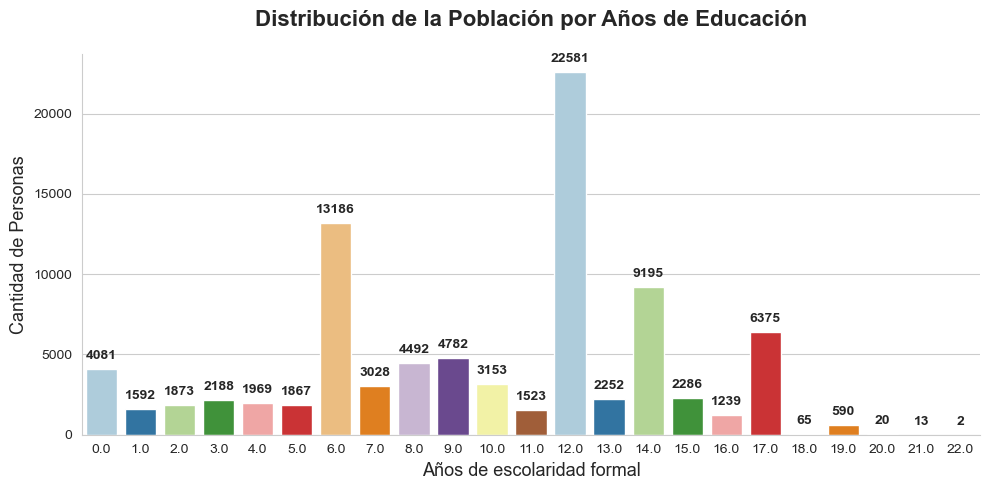

In [15]:
#configuración de estilo
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

# creación del gráfico
ax = sns.countplot(
    data=t1_2425_3, 
    x="educ", 
    palette="Paired", 
    hue="educ",
    legend=False
)

# etiquetas
plt.title("Distribución de la Población por Años de Educación", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Años de escolaridad formal", fontsize=13)
plt.ylabel("Cantidad de Personas", fontsize=13)

# Añadir etiquetas de valor sobre cada barra para evitar ambigüedades
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha="center", va="bottom", 
                    fontsize=10, fontweight="bold",
                    xytext=(0, 5), textcoords="offset points")

# elimino bordes
sns.despine()
plt.tight_layout()

plt.show()

In [16]:
#creo horastrab
t1_2425_3["horastrab"] = t1_2425_3["PP3E_TOT"] + t1_2425_3["PP3F_TOT"]

In [17]:
t1_2425_3.sample(8)

,CODUSU,ANO4,REGION,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,PP04A,COMPONENTE,PP3E_TOT,PP3F_TOT,CH12,CH13,CH14,edad2,educ,horastrab
3624,TQRMNOSRSHLMLLCDEOJAH00856228,2024,44,1,78,2,16.0,5,1.0,3,...,NaN,4,NaN,NaN,4,2,4.0,256.0,10.0,NaN
81072,TQRMNORUQHJKLLCDEGJBF00872771,2025,43,1,1450,2,79.0,4,1.0,1,...,NaN,1,NaN,NaN,2,2,2.0,6241.0,2.0,NaN
23919,TQRMNOSPVHMOKPCDEGGFB00799473,2024,42,1,493,2,17.0,1,4.0,3,...,NaN,3,NaN,NaN,4,2,2.0,289.0,8.0,NaN
40713,TQRMNORQTHJLKOCDEGGFB00796822,2024,42,1,643,2,7.0,5,1.0,1,...,NaN,4,NaN,NaN,2,2,1.0,49.0,1.0,NaN
40772,TQRMNOPTTHJOKNCDEFNFF00795194,2024,41,1,357,1,9.0,5,4.0,1,...,NaN,7,NaN,NaN,2,2,2.0,81.0,2.0,NaN
37671,TQRMNOSTXHKOLQCDEFPCH00858689,2024,44,1,268,1,69.0,2,4.0,1,...,2.0,1,48.0,0.0,2,2,2.0,4761.0,2.0,48.0
7351,TQRMNOQWXHKNLQCDEGPDJ00859431,2024,40,1,160,1,70.0,1,1.0,2,...,NaN,1,NaN,NaN,2,1,NaN,4900.0,6.0,NaN
57846,TQRMNOSUQHKMKPCDEFOCD00859604,2025,41,1,260,1,48.0,2,2.0,6,...,2.0,1,60.0,0.0,6,1,NaN,2304.0,14.0,60.0


C:\Users\lilir\AppData\Local\Temp\ipykernel_5748\934777592.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


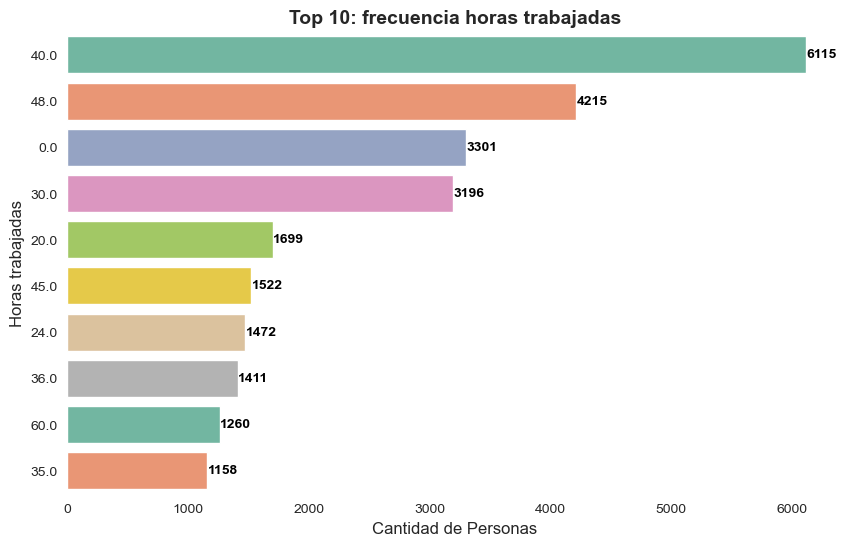

In [18]:
# obtengo el top 10 de mayor frecuencia de horastrab
top_10 = t1_2425_3["horastrab"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.set_style("white")

# creo el grafico de barras horizontales
ax = sns.barplot(
    x=top_10.values, 
    y=top_10.index.astype(str), # Convertimos a string para que sea categórico
    palette='Set2'
)

#etiquetas
plt.title("Top 10: frecuencia horas trabajadas", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad de Personas", fontsize=12)
plt.ylabel("Horas trabajadas", fontsize=12)

# lineas para añadir las frecuencias al final de la barra
for i, v in enumerate(top_10.values):
    ax.text(v + 3, i, str(int(v)), color="black", va="center", fontweight="bold")

sns.despine(left=True, bottom=True)
plt.show()

In [19]:
# creo la variable nhogar
# todos los miebros del hogar tienen el mismo CODUSU y NRO_HOGAR, los diferencia COMPONENTE
t1_2425_3["nhogar"] = t1_2425_3.groupby(["CODUSU", "NRO_HOGAR"])["COMPONENTE"].transform("count")


print(t1_2425_3[["CODUSU", "NRO_HOGAR", "nhogar"]].head())

                          CODUSU  NRO_HOGAR  nhogar
0  TQRMNOSTSHJOLOCDEHLEH00795168          1       1
1  TQRMNOSQYHJMLPCDEIKAH00793199          1       2
2  TQRMNOSQYHJMLPCDEIKAH00793199          1       2
3  TQRMNORWPHJOLLCDEGPDJ00795996          1       1
4  TQRMNOTQRHJMLOCDEHJGH00794657          1       4


In [20]:
t1_2425_3["nhogar"].max()

25

In [21]:
# creo variable para que el grafico no quede sobrerepresntado, si nhogar es 3, cada persona cuenta como 1/3 de un hogar
t1_2425_3["peso_hogar"] = 1 / t1_2425_3["nhogar"]

In [22]:
dist_corregida = t1_2425_3.groupby('nhogar')['peso_hogar'].sum().reset_index()

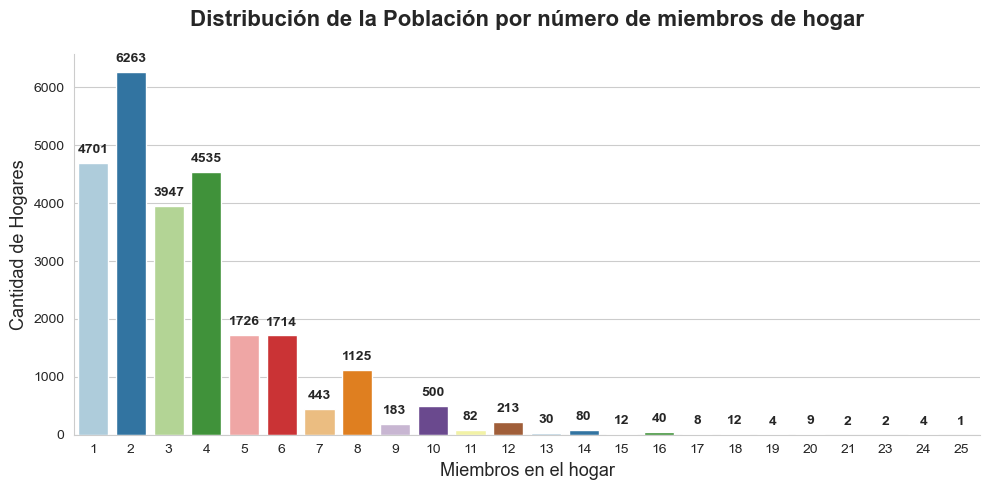

In [23]:
# grafico de barras
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=dist_corregida, 
    x="nhogar", 
    y="peso_hogar", 
    palette="Paired", 
    hue="nhogar",
    legend=False
)

# etiquetas
plt.title("Distribución de la Población por número de miembros de hogar", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Miembros en el hogar", fontsize=13)
plt.ylabel("Cantidad de Hogares", fontsize=13)

# Añadir etiquetas de valor sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # round e int para que el número sobre la barra sea prolijo
        ax.annotate(f'{int(round(height))}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha="center", va="bottom", 
                    fontsize=10, fontweight="bold",
                    xytext=(0, 5), textcoords="offset points")

# elimino bordes
sns.despine()
plt.tight_layout()

plt.show()

In [24]:
t1_2425_3.sample(8)

,CODUSU,ANO4,REGION,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,PP3E_TOT,PP3F_TOT,CH12,CH13,CH14,edad2,educ,horastrab,nhogar,peso_hogar
17229,TQRMNOSTPHKOKPCDEGIBJ00857082,2024,41,1,344,1,39.0,5,4.0,6,...,50.0,0.0,7,1,NaN,1521.0,17.0,50.0,6,0.166667
35127,TQRMNOXPSHMOLRCDEIJAH00802225,2024,1,1,2411,1,10.0,5,1.0,1,...,NaN,NaN,2,2,3.0,100.0,3.0,NaN,6,0.166667
56344,TQRMNOQWQHLMTMCDEIJAH00855593,2025,1,1,2422,1,24.0,5,1.0,4,...,48.0,0.0,4,1,NaN,576.0,12.0,48.0,7,0.142857
30452,TQRMNOPUWHLMKQCDEGGFB00852664,2024,42,1,475,1,13.0,5,1.0,3,...,NaN,NaN,4,2,0.0,169.0,6.0,NaN,8,0.125000
64819,TQRMNOQSPHLMMOCDEGJBF00873965,2025,43,1,619,2,58.0,2,1.0,6,...,0.0,0.0,6,1,NaN,3364.0,14.0,0.0,4,0.250000
60956,TQRMNORPXHLMLQCDEIKAH00858491,2025,43,1,521,2,23.0,5,1.0,5,...,20.0,0.0,7,2,3.0,529.0,15.0,20.0,4,0.250000
64943,TQRMNOPVRHKNMOCDEGJBF00860269,2025,43,1,475,2,36.0,1,1.0,5,...,20.0,0.0,6,2,2.0,1296.0,14.0,20.0,4,0.250000
79945,TQRMNOQWTHKMLNCDEGPDJ00857492,2025,40,1,189,1,24.0,5,1.0,4,...,36.0,0.0,4,1,NaN,576.0,12.0,36.0,12,0.083333


In [25]:
# transformo las columnas en formato float para evitar error
t1_2425_3["P21"] = t1_2425_3["P21"].astype(float)
t1_2425_3["P47T"] = t1_2425_3["P47T"].astype(float)

In [26]:
mult = round(8353.3 / 5357.1, 2)
mult

1.56

In [27]:
# aplico el multiplicador de inflación solo a las filas del 2024
a24 = t1_2425["ANO4"] == 2024
t1_2425.loc[a24, "P21"] *= mult
t1_2425.loc[a24, "P47T"] *= mult

## Estadística descriptiva

In [28]:
#dado que el codigo 99 o 999 significa que no contestó, para las columnas de horas trabajadas y la cantidad de personas que trabajan en su ocupación
cols = ["PP04C", "PP3E_TOT", "PP3F_TOT"]
t1_2425_3[cols] = t1_2425_3[cols].where(t1_2425_3[cols] <= 95, np.nan)

In [29]:
#utilizo la funcion describe, sacando las columnas que no tiene sentido analizar
t1_2425_3.drop(columns=["ANO4", "PP04A","peso_hogar", "COMPONENTE", "REGION", "CH04", "CH08", "EMPLEO", "SECTOR", "CAT_OCUP", "CH07", "ESTADO", "CH12", "CH13", "CH14", "PP04D_COD"]).describe().round(2)

,NRO_HOGAR,PONDERA,CH06,NIVEL_ED,PP04C,P21,P47T,PP04G,PP3E_TOT,PP3F_TOT,edad2,educ,horastrab,nhogar
count,91475.00,91475.00,90851.00,91475.00,34864.00,84233.00,81052.00,40401.00,40211.00,40393.00,90851.00,88352.00,40401.00,91475.00
mean,1.03,649.80,36.80,3.75,5.03,197145.57,327321.38,9.03,33.57,1.24,1839.56,9.75,36.72,5.37
std,0.64,862.56,22.03,1.74,3.79,442957.53,576952.09,3.30,18.04,4.87,1851.59,4.60,46.07,3.38
min,1.00,21.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
25%,1.00,178.00,18.00,3.00,1.00,0.00,0.00,8.00,20.00,0.00,324.00,6.00,24.00,3.00
50%,1.00,320.00,35.00,4.00,5.00,0.00,150000.00,11.00,36.00,0.00,1225.00,12.00,40.00,4.00
75%,1.00,667.00,53.00,5.00,8.00,250000.00,445000.00,11.00,45.00,0.00,2809.00,12.00,48.00,7.00
max,72.00,8685.00,103.00,7.00,12.00,25000000.00,32600000.00,13.00,95.00,76.00,10609.00,22.00,1998.00,25.00


## Matriz de correlaciones

In [30]:
#creacion de variables para definir ocupados
respondieron = t1_2425_3[t1_2425_3["ESTADO"] != 0]
norespondieron = t1_2425_3[t1_2425_3["ESTADO"] == 0]

ocupados = respondieron[respondieron["ESTADO"] == 1]
ocupados.head()

,CODUSU,ANO4,REGION,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,PP3E_TOT,PP3F_TOT,CH12,CH13,CH14,edad2,educ,horastrab,nhogar,peso_hogar
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,43,1,648,1,68.0,3,1.0,2,...,6.0,0.0,2,1,NaN,4624.0,6.0,6.0,2,0.50
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,2,41.0,1,1.0,4,...,12.0,0.0,4,1,NaN,1681.0,12.0,12.0,4,0.25
5,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,1,42.0,1,1.0,6,...,48.0,0.0,7,1,NaN,1764.0,17.0,48.0,4,0.25
8,TQRMNORWQHJMKPCDEIKAH00794680,2024,43,1,513,1,29.0,2,1.0,5,...,48.0,0.0,6,2,1.0,841.0,13.0,48.0,2,0.50
10,TQRMNORXSHJMLQCDEGPDJ00794708,2024,40,1,193,2,31.0,1,4.0,4,...,20.0,12.0,4,1,NaN,961.0,12.0,32.0,4,0.25


Para esta definición de informalidad, las condiciones son las siguientes

1- ESTADO = 1, CAT. OCUP. = 1, NªTRABAJADORES = 1 2 3 4 5

2- ESTADO = 1, CAT. OCUP. = 2, NIVEL ED. = 1 2 3 4 5

3- ESTADO = 1, CAT. OCUP. = 4

In [31]:
# definimos la función para aplicar las reglas de informalidad 
def informalidad(row):
    # propietarios en empresas de hasta cinco empleados
    if row["CAT_OCUP"] == 1 and row["PP04C"] in [1, 2, 3, 4]:
        return "1"
    # trabajadores por cuenta propia no profesionales (hasta universitario/terciario incompleto)
    if row["CAT_OCUP"] == 2 and row["NIVEL_ED"] in [1, 2, 3, 4, 5]:
        return "1"
    # trabajadores familiares no remunerados
    if row["CAT_OCUP"] == 4:
        return "1"
    # el resto de los ocupados se consideran formales
    if row["ESTADO"] == 1:
        return "0"
    return np.nan

# agrego la función como columna al dataset de ocupados
ocupados["INFORMAL/FORMAL"] = ocupados.apply(informalidad, axis=1)

C:\Users\lilir\AppData\Local\Temp\ipykernel_5748\749902778.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ocupados["INFORMAL/FORMAL"] = ocupados.apply(informalidad, axis=1)


In [32]:
ocupados.head()

,CODUSU,ANO4,REGION,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,PP3F_TOT,CH12,CH13,CH14,edad2,educ,horastrab,nhogar,peso_hogar,INFORMAL/FORMAL
1,TQRMNOSQYHJMLPCDEIKAH00793199,2024,43,1,648,1,68.0,3,1.0,2,...,0.0,2,1,NaN,4624.0,6.0,6.0,2,0.50,1
4,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,2,41.0,1,1.0,4,...,0.0,4,1,NaN,1681.0,12.0,12.0,4,0.25,1
5,TQRMNOTQRHJMLOCDEHJGH00794657,2024,40,1,252,1,42.0,1,1.0,6,...,0.0,7,1,NaN,1764.0,17.0,48.0,4,0.25,0
8,TQRMNORWQHJMKPCDEIKAH00794680,2024,43,1,513,1,29.0,2,1.0,5,...,0.0,6,2,1.0,841.0,13.0,48.0,2,0.50,0
10,TQRMNORXSHJMLQCDEGPDJ00794708,2024,40,1,193,2,31.0,1,4.0,4,...,12.0,4,1,NaN,961.0,12.0,32.0,4,0.25,1


In [33]:
#utilizo la funcion describe, sacando las columnas que no tiene sentido analizar
ocupados.drop(columns=["ANO4", "PP04A","peso_hogar", "COMPONENTE", "REGION", "CH04", "CH08", "EMPLEO", "SECTOR", "CAT_OCUP", "CH07", "ESTADO", "CH12", "CH13", "CH14", "PP04D_COD"]).describe().round(2)

,NRO_HOGAR,PONDERA,CH06,NIVEL_ED,PP04C,P21,P47T,PP04G,PP3E_TOT,PP3F_TOT,edad2,educ,horastrab,nhogar
count,40401.00,40401.00,40401.00,40401.00,34864.00,33159.00,32475.00,40401.00,40211.00,40393.00,40401.00,40336.00,40401.00,40401.00
mean,1.04,652.77,41.19,4.17,5.03,500804.08,625449.02,9.03,33.57,1.24,1866.82,11.79,36.72,5.03
std,0.95,836.51,13.05,1.38,3.79,588525.33,744363.65,3.30,18.04,4.87,1143.57,3.59,46.07,3.19
min,1.00,21.00,10.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,1.00
25%,1.00,180.00,31.00,3.00,1.00,180000.00,220000.00,8.00,20.00,0.00,961.00,9.00,24.00,3.00
50%,1.00,325.00,40.00,4.00,5.00,350000.00,420000.00,11.00,36.00,0.00,1600.00,12.00,40.00,4.00
75%,1.00,690.00,51.00,5.00,8.00,680000.00,800000.00,11.00,45.00,0.00,2601.00,14.00,48.00,6.00
max,72.00,8685.00,99.00,7.00,12.00,25000000.00,32600000.00,13.00,95.00,76.00,9801.00,22.00,1998.00,25.00


In [34]:
# cambio el nobre de variables para mejor legibilidad del gráfico
ocupados.rename(columns={"CH06": "Edad", "edad2": "Edad2", "PP04C": "Nª Trab", "P21": "ING. PRINC."}, inplace=True)

C:\Users\lilir\AppData\Local\Temp\ipykernel_5748\2864239826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ocupados.rename(columns={"CH06": "Edad", "edad2": "Edad2", "PP04C": "Nª Trab", "P21": "ING. PRINC."}, inplace=True)


In [35]:
ocupados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40401 entries, 1 to 91474
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CODUSU           40401 non-null  object 
 1   ANO4             40401 non-null  int64  
 2   REGION           40401 non-null  int64  
 3   NRO_HOGAR        40401 non-null  int64  
 4   PONDERA          40401 non-null  int64  
 5   CH04             40401 non-null  int64  
 6   Edad             40401 non-null  float64
 7   CH07             40401 non-null  int64  
 8   CH08             40400 non-null  float64
 9   NIVEL_ED         40401 non-null  int64  
 10  ESTADO           40401 non-null  int64  
 11  CAT_OCUP         40401 non-null  int64  
 12  EMPLEO           40401 non-null  float64
 13  SECTOR           40401 non-null  float64
 14  Nª Trab          34864 non-null  float64
 15  PP04D_COD        40401 non-null  float64
 16  ING. PRINC.      33159 non-null  float64
 17  P47T             

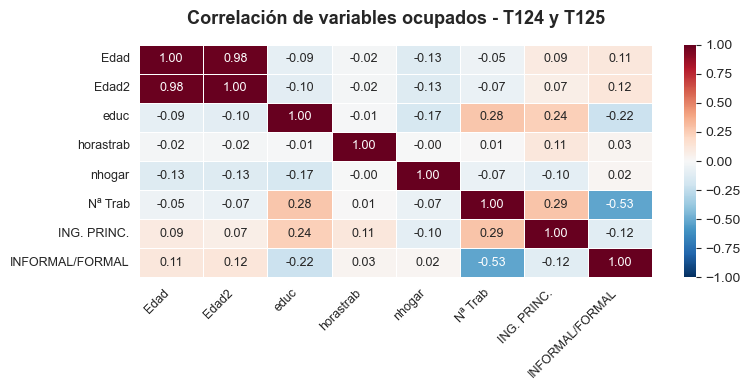

In [36]:
# matriz de correlación
#selecciono columnas a analizar
cols_seleccionadas = ["Edad", "Edad2", "educ", "horastrab", "nhogar", "Nª Trab", "ING. PRINC.", "INFORMAL/FORMAL"]

plt.figure(figsize=(8, 4))
sns.heatmap(
    ocupados[cols_seleccionadas].corr(),
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    cmap="RdBu_r",
    annot_kws={"size": 9},
    linewidths=0.5,       
    linecolor='white'
)
plt.title("Correlación de variables ocupados - T124 y T125", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


# Parte II: Métodos no Supervisados

In [37]:
#Instalamos los paquetes necesarios
!pip install statsmodels
!pip install scikit-learn
!pip install ISLP

In [38]:
import ISLP
from ISLP import load_data
from statsmodels.datasets import get_rdataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [39]:
# inicio el transformador
# defino variable con las columnas a analizar, sin CODUSU para que no salte error.
cols_selec = ["Edad", "Edad2", "educ", "horastrab", "nhogar", "Nª Trab", "ING. PRINC."]
oc_numerico = ocupados[cols_selec]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(oc_numerico)

# Aplicamos fit_transform al DataFrame
ocupados_scaled = pd.DataFrame(data_scaled, columns=cols_selec)

In [40]:
# Chequeamos que tengan media 0 y desvio estandar 1
print("Promedio luego de la transformación\n",ocupados_scaled.mean()) # luego de la estandarización la media es cero
print("Desvío estandár luego de la transformación\n",ocupados_scaled.std()) # la desviación estandar es uno

Promedio luego de la transformación
 Edad           1.927563e-16
Edad2          5.768620e-17
educ          -2.092733e-16
horastrab      3.517451e-18
nhogar        -1.406980e-18
Nª Trab       -1.173912e-16
ING. PRINC.   -5.485658e-17
dtype: float64
Desvío estandár luego de la transformación
 Edad           1.000012
Edad2          1.000012
educ           1.000012
horastrab      1.000012
nhogar         1.000012
Nª Trab        1.000014
ING. PRINC.    1.000015
dtype: float64


In [41]:
# Visualizamos
ocupados_scaled.head().round(3)

,Edad,Edad2,educ,horastrab,nhogar,Nª Trab,ING. PRINC.
0,2.055,2.411,-1.612,-0.667,-0.949,-1.064,-0.596
1,-0.015,-0.162,0.058,-0.537,-0.322,-1.064,-0.426
2,0.062,-0.090,1.451,0.245,-0.322,-0.800,0.254
3,-0.934,-0.897,0.337,0.245,-0.949,0.783,-0.375
4,-0.781,-0.792,0.058,-0.102,-0.322,-1.064,-0.766


In [42]:
ocupados_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40401 entries, 0 to 40400
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Edad         40401 non-null  float64
 1   Edad2        40401 non-null  float64
 2   educ         40336 non-null  float64
 3   horastrab    40401 non-null  float64
 4   nhogar       40401 non-null  float64
 5   Nª Trab      34864 non-null  float64
 6   ING. PRINC.  33159 non-null  float64
dtypes: float64(7)
memory usage: 2.2 MB


Aplico PCA

Por la presencia de datos nulos en Ingreso Principal, Nª Trab y educ, utilizo IterativeImputer, sugerido por Gemini

In [43]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [44]:
# IterativeImputer estima el ingreso de la persona basándose en su edad, educación y horas trabajadas.
imputer = IterativeImputer(random_state=42)
ocupados_completos = imputer.fit_transform(ocupados_scaled)

# aplico PCA
pca = PCA()
ocupados_pca = pca.fit_transform(ocupados_completos)

# ver cuánta varianza explicas
print("\nVarianza explicada (Caso IterativeImputer):")
print(pca.explained_variance_ratio_)


Varianza explicada (Caso IterativeImputer):
[0.30285095 0.22760152 0.15753123 0.13287488 0.09649112 0.0804592
 0.00219111]


Se llega al 80% con los primeros cuatro componentes

In [45]:
# para comparar resultados veo el caso de eliminar los datos nulos
ocupados_nonul = ocupados_scaled.dropna().copy()

# filas perdidas
filas_originales = len(ocupados_scaled)
filas_finales = len(ocupados_nonul)
print(f"Filas eliminadas: {filas_originales - filas_finales}")
print(f"Porcentaje de datos conservados: {(filas_finales / filas_originales) * 100:.2f}%")

# PCA sobre dataset con filas borradas
pca_drop = PCA()
pca_results_drop = pca_drop.fit_transform(ocupados_nonul)

# varianza explicada
print("\nVarianza explicada (Caso dropna):")
print(pca_drop.explained_variance_ratio_)

Filas eliminadas: 11077
Porcentaje de datos conservados: 72.58%

Varianza explicada (Caso dropna):
[0.31045789 0.25652676 0.15180048 0.11501741 0.10806551 0.05592784
 0.00220411]


Al tener resultados muy parecidos, me quedo con el caso de IterativeImputer por tener mayores muestras

In [46]:
scores = ocupados_pca
scores

array([[ 3.44169616, -1.54486446, -0.52028706, ..., -0.52117795,
         0.18441825,  0.22270759],
       [-0.03036713, -0.69659103, -0.63110298, ...,  0.54108868,
         0.44311751, -0.12143165],
       [-0.05341393,  0.73747142, -0.15358235, ...,  1.42695492,
         0.40879534, -0.10639645],
       ...,
       [-1.79108152,  1.93690426, -0.0993818 , ..., -0.26357716,
        -0.01262189,  0.1613743 ],
       [ 0.33579581,  1.83533594,  0.67075458, ..., -0.51046418,
         3.94386197, -0.06548339],
       [-1.79716053,  2.07918663,  0.39534567, ..., -0.702862  ,
         1.36011646,  0.24560488]], shape=(40401, 7))

In [47]:
# Loadings vectors (ponderadores, en ecuacion 4 son los phi.

loading_vectors = pca.components_ # cada fila corresponde a un CP y cada columna, a una variable
print("Loadings:\n", pca.components_)
print("Loadings del CP1:\n",pca.components_[0]) 
pca.components_[0,0] #loadings del CP1 variable 1, phi(1,1) en ecuacion 4
print("Loadings del CP2:\n",pca.components_[1]) 

Loadings:
 [[ 6.90868853e-01  6.91763623e-01 -1.04859520e-01 -1.13594740e-02
  -1.54390898e-01 -6.73479079e-02  6.83115681e-02]
 [ 1.49603293e-02 -2.62504739e-03  5.85037576e-01  1.77879064e-01
  -3.43350193e-01  4.93904919e-01  5.13836499e-01]
 [ 7.17426030e-03  3.47609401e-03 -2.65866746e-01  8.65989966e-01
   3.14842035e-01 -6.50202684e-02  2.75607614e-01]
 [ 1.14730291e-01  9.94317656e-02  1.00454534e-01 -3.07122904e-01
   8.35669605e-01  3.71279752e-01  1.90636693e-01]
 [ 6.69831734e-02  7.11645756e-02  7.44697691e-01  1.64726391e-01
   2.46379735e-01 -5.50118346e-01 -2.13087434e-01]
 [-7.36269720e-02 -7.83965951e-02 -1.06573332e-01 -3.11178368e-01
  -8.80797526e-03 -5.53822939e-01  7.57262017e-01]
 [-7.06650005e-01  7.07352116e-01  5.17207354e-03 -3.75324153e-04
   4.93410122e-03  9.79070768e-03  1.23150078e-02]]
Loadings del CP1:
 [ 0.69086885  0.69176362 -0.10485952 -0.01135947 -0.1543909  -0.06734791
  0.06831157]
Loadings del CP2:
 [ 0.01496033 -0.00262505  0.58503758  0.1778

Gráfico de dispersión

In [48]:
# Creamos un DataFrame con los scores del PCA (PC1 y PC2)
# Usamos ocupados_pca que generaste con el IterativeImputer
df_pca = pd.DataFrame(data=ocupados_pca[:, :2], columns=['PC1', 'PC2'])

df_pca['estado_laboral'] = ocupados['INFORMAL/FORMAL'].values

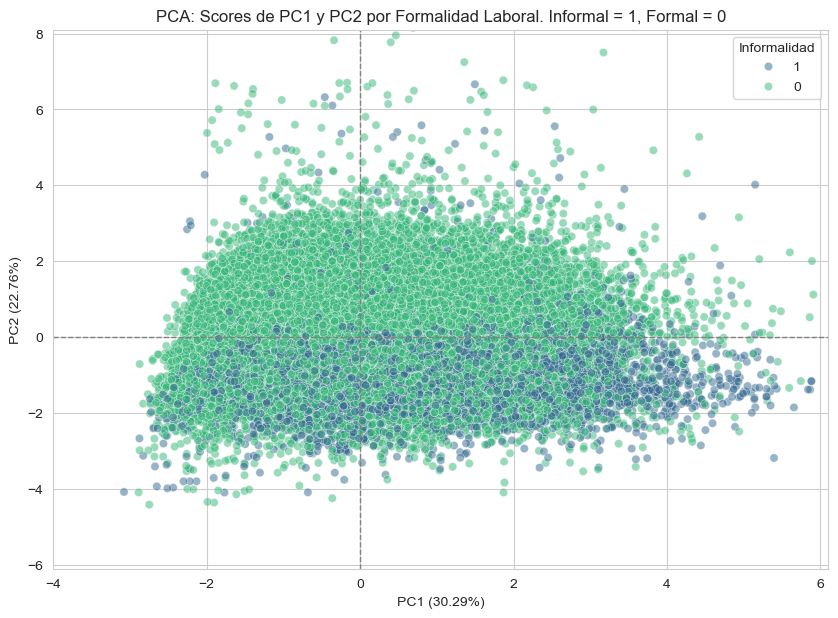

In [49]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="PC1", 
    y="PC2", 
    hue="estado_laboral", 
    data=df_pca, 
    alpha=0.5, 
    palette="viridis"
)

plt.title('PCA: Scores de PC1 y PC2 por Formalidad Laboral. Informal = 1, Formal = 0')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylim(-6.1,8.1) #-6.1,8.1
plt.xlim(-4,6.1) #-4,8
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.legend(title='Informalidad', loc='best')

plt.show()

Flechas con ponderadores

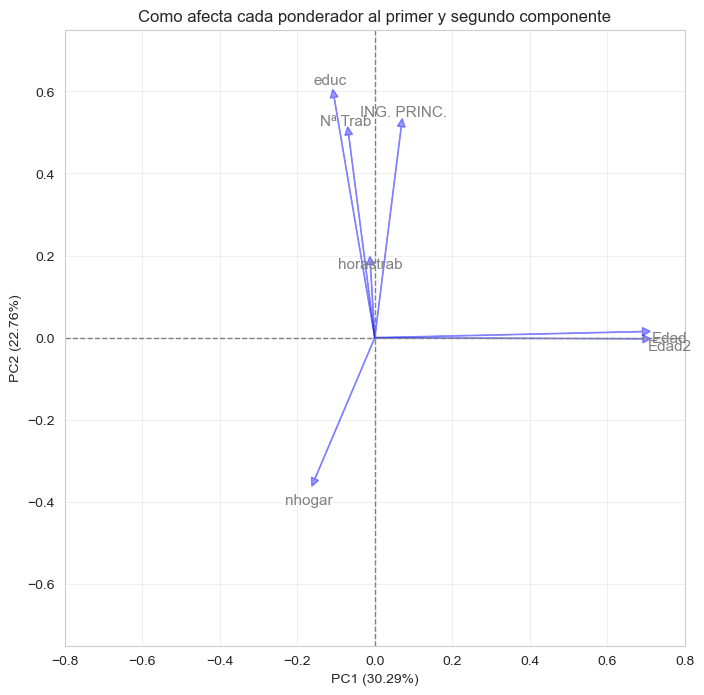

In [50]:
# extraigo componentes y columnas a analizar en el PCA
loadings = pca.components_.T 
variables = ocupados[cols_selec].columns 

# configuro el grafico
plt.figure(figsize=(8, 8))
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# etiquetas y flechas
for i, var_name in enumerate(variables):
    # loadings para PC1 (índice 0) y PC2 (índice 1)
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
              color='blue', alpha=0.4, head_width=0.02, head_length=0.02)
    
    # Ajustamos el texto para que no se pegue a la punta de la flecha
    plt.text(loadings[i, 0] * 1.1, loadings[i, 1] * 1.1, 
             var_name, color='gray', ha='center', va='top', fontsize=11)

plt.xlim(-0.8, 0.8)
plt.ylim(-0.75, 0.75)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title("Como afecta cada ponderador al primer y segundo componente")
plt.grid(True, alpha=0.3)
plt.show()

Proporcion de varianza explicada

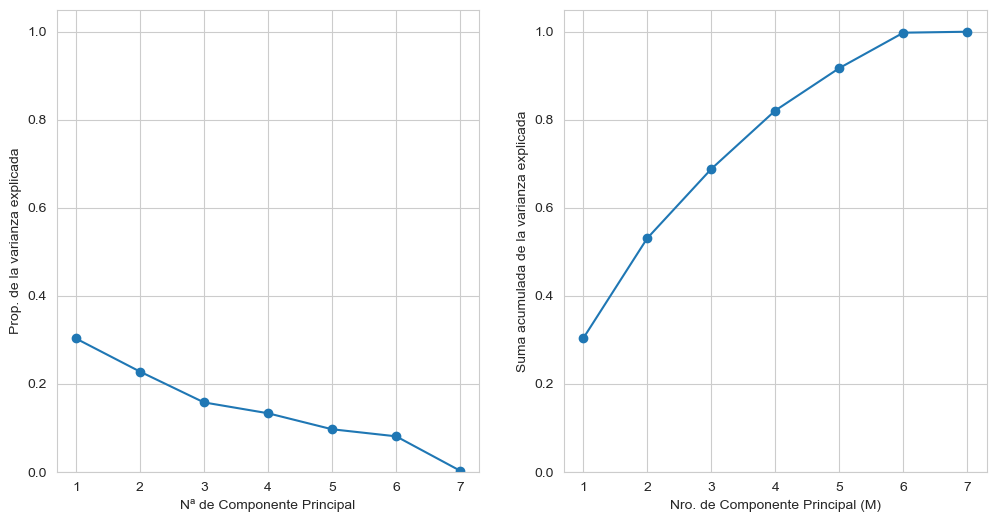

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) # 2 subplots uno al lado del otro
ticks = np.arange(pca.n_components_)+1 
ax = axes[0]
ax.plot(ticks, pca.explained_variance_ratio_ , marker='o')
ax.set_xlabel("Nª de Componente Principal");
ax.set_ylabel("Prop. de la varianza explicada")
ax.set_ylim([0,1.05])
ax.set_xticks(ticks)
# capture suprime la visualización de la figura parcialmente terminada
ax = axes[1]
ax.plot(ticks, pca.explained_variance_ratio_.cumsum(), marker='o') 
ax.set_xlabel("Nro. de Componente Principal (M)")
ax.set_ylabel("Suma acumulada de la varianza explicada")
ax.set_ylim([0, 1.05])
ax.set_xticks(ticks)

# Cluster

In [94]:
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.ticker as ticker

In [60]:
# selección de variables y limpieza 
cols_selec = ["Edad", "Edad2", "educ", "horastrab", "nhogar", "Nª Trab", "ING. PRINC."]
oc_limpio = ocupados[cols_selec].dropna()

# transformación
scaler = StandardScaler()
ocupados_tf = scaler.fit_transform(oc_limpio)

In [57]:
kmeans2 = KMeans(n_clusters=2, random_state=10, init="random", n_init=20).fit(oc_limpio)

In [58]:
kmeans2.labels_

array([0, 0, 0, ..., 0, 0, 1], shape=(29324,), dtype=int32)

In [62]:
clusters = kmeans_2.fit_predict(ocupados_tf)

oc_limpio["X"] = clusters

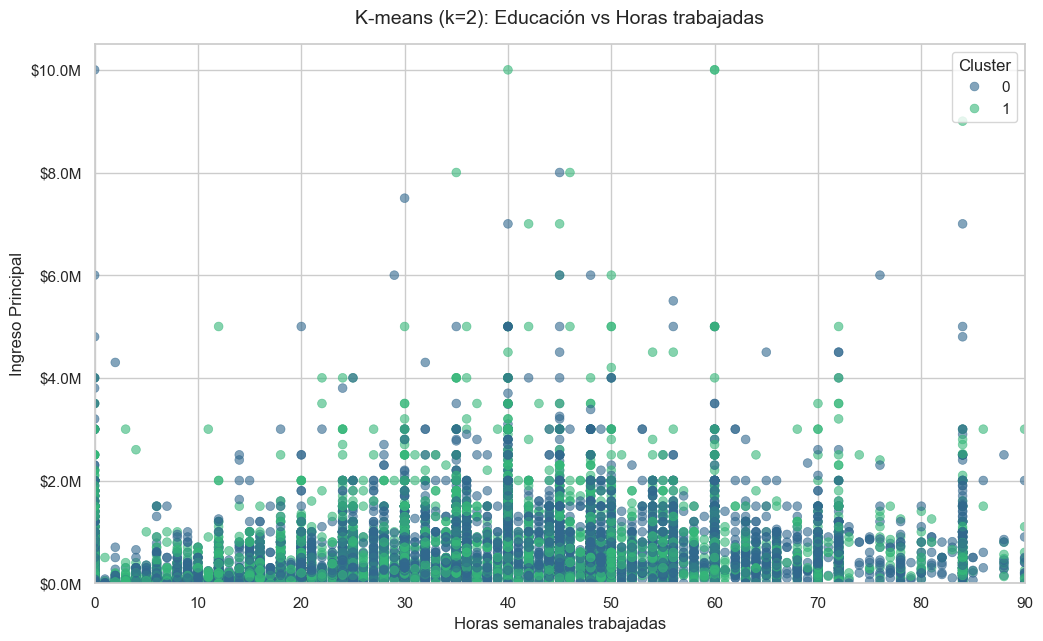

In [98]:
# grafico usando dos variables, educ e ing. princ.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# distribución de puntos
scatter = sns.scatterplot(
    data=oc_limpio,
    x="horastrab",
    y="ING. PRINC.",
    hue="X",           
    palette="viridis", 
    alpha=0.6,         
    edgecolor=None,    
    s=40               
)

# etiquetas
plt.title("K-means (k=2): Educación vs Horas trabajadas", fontsize=14, pad=15)
plt.xlabel("Horas semanales trabajadas", fontsize=12)
plt.ylabel("Ingreso Principal", fontsize=12)

plt.xlim(0, 90)
plt.ylim(0, 10500000)
plt.legend(title="Cluster", loc="upper right")

# modificaciones para mejor legibilidad
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"${v/1_000_000:.1f}M"))

plt.show()

In [112]:
# Posibles valores del número de clúster
n_cluster_range = range(1,40)

# Objeto para guardar los valores de inertia
inertia_values = []

# Loop para probar distintos valores de cluster
for n_clusters in n_cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(ocupados_tf)
    inertia_values.append(kmeans.inertia_)
 

<function matplotlib.pyplot.show(close=None, block=None)>

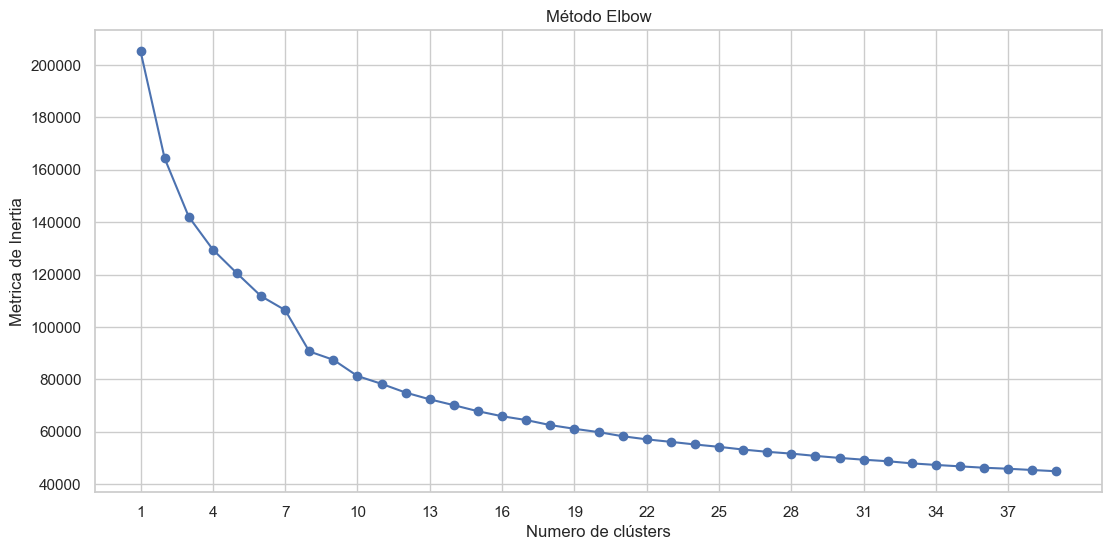

In [113]:
# Ahora graficamos como cambia inertia con los distintos clusters
plt.figure(figsize=(13, 6))
plt.plot(n_cluster_range,inertia_values, marker='o')
plt.xlabel('Numero de clústers')
plt.ylabel('Metrica de Inertia')
plt.title('Método Elbow')
plt.xticks(range(min(n_cluster_range), max(n_cluster_range) + 1, 3))
plt.show

Cluster jerarquico

In [109]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris

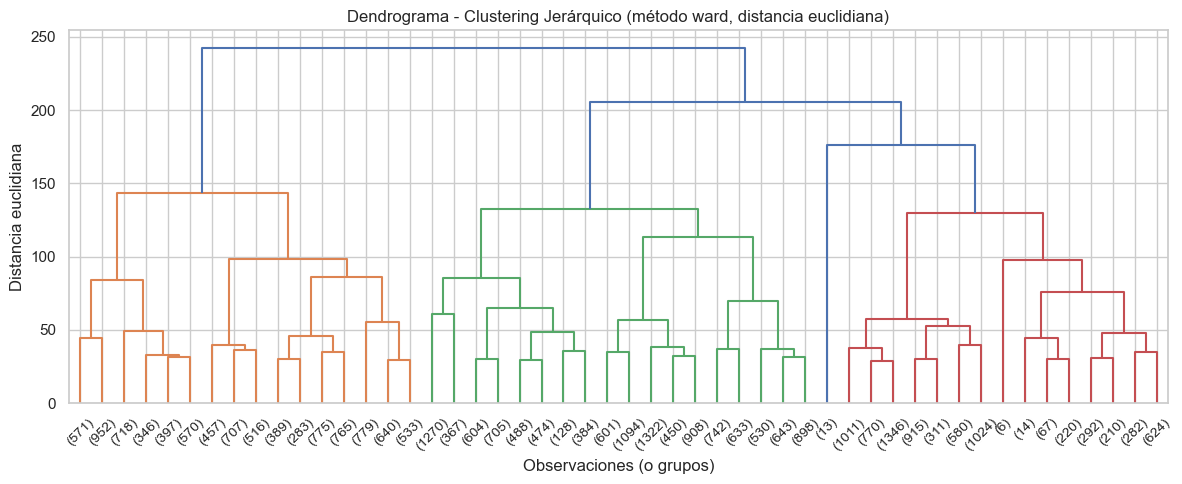

In [123]:
X = ocupados[cols_selec].dropna() 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# cluster jerarquico
Z = linkage(X_scaled, method='ward', metric='euclidean')

# grafico de dendograma
plt.figure(figsize=(12, 5))
dendrogram(Z,  truncate_mode='lastp', p=50, leaf_rotation=45, leaf_font_size=10)
plt.title("Dendrograma - Clustering Jerárquico (método ward, distancia euclidiana)")
plt.xlabel("Observaciones (o grupos)")
plt.ylabel("Distancia euclidiana")
plt.tight_layout()
plt.show()